In [155]:
import pandas as pd
from ydata_profiling import ProfileReport
data = pd.read_csv('../data/train.csv')
data.drop(columns=['area_business'], inplace=True)

In [ ]:
doc_id
송장의 고유 식별자(각 숫자별 의미를 찾고 있으나 없다고 판단되면 삭제)(deleted)

- **invoice_currency**
송장 금액에 사용된 통화 단위(캐나다 달러를 미국 달러로 환산 후 삭제)

- **document type**
문서의 유형을 나타내는 변수
예: **D1**은 송장(invoice)을 의미(deleted)

- **posting_id**
해당 항목이 매출채권(AR) 기준에서 송장(invoice), 차감(deduction), 대변전표(credit memo) 중 무엇인지 구분하는 지표(deleted)
SAP ERP에서 사용됨

- **invoice_id**
판매자가 송장을 생성할 때 부여하는 고유 번호(deleted)

- **isOpen**
송장이 미결 상태인지 여부를 나타내는 변수`isOpen = 1`이면 아직 열려 있는 송장, 즉 미결제 상태를 의미(deleted)

- **total_open_amount**
해당 송장에서 아직 지급되지 않은 미결제 금액

- **cust_payment_terms**
고객과 계정 간에 합의된 결제 조건
예: 할인 조건, 지급 기한 등

SyntaxError: invalid syntax (1564981532.py, line 2)

In [122]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000 entries, 0 to 31999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   business_code           32000 non-null  object 
 1   cust_number             32000 non-null  object 
 2   name_customer           32000 non-null  object 
 3   clear_date              32000 non-null  object 
 4   buisness_year           32000 non-null  float64
 5   doc_id                  32000 non-null  float64
 6   posting_date            32000 non-null  object 
 7   document_create_date    32000 non-null  int64  
 8   document_create_date.1  32000 non-null  int64  
 9   due_in_date             32000 non-null  object 
 10  invoice_currency        32000 non-null  object 
 11  document type           32000 non-null  object 
 12  posting_id              32000 non-null  float64
 13  total_open_amount       32000 non-null  float64
 14  baseline_create_date    32000 non-null

In [156]:
#doc_id가 invoice_id이 6개만 다른것이 존재하기에 결측치가 있는invoice_id열 제거
diff_rows = data[data["doc_id"] != data["invoice_id"]]

print(diff_rows[["doc_id", "invoice_id"]])
print("다른 행 개수:", len(diff_rows))
data.drop(columns=['invoice_id'], inplace=True)

            doc_id  invoice_id
8526  9.500000e+09         NaN
8539  9.500000e+09         NaN
8572  9.500000e+09         NaN
8598  9.500000e+09         NaN
8606  9.500000e+09         NaN
8616  9.500000e+09         NaN
다른 행 개수: 6


In [124]:
data['posting_date'] = pd.to_datetime(data['posting_date'], errors = 'coerce').sort_values()

In [159]:
data['invoice_currency'].value_counts() 

invoice_currency
USD    29405
CAD     2595
Name: count, dtype: int64

In [157]:
#21 외화 거래 는 최초 인식 시 기능 통화 로 기록되며 , 외화 금액에 거래일의 기능 통화와 외화 간의 현물 환율을 적용합니다 . [ 참조: 22항 ]
#22거래일이란 IFRS에 따라 해당 거래가 최초로 인식 요건을 충족하는 날짜를 말합니다. 
#실무적인 이유로 거래일의 실제 환율과 유사한 환율을 사용하는 경우가 많습니다. 예를 들어, 특정 기간 동안 발생한 모든 외화 거래에 대해 일주일 또는 한 달 동안의 평균 환율을 사용할 수 있습니다. 
#그러나 환율 변동이 심한 경우에는 특정 기간의 평균 환율을 사용하는 것이 적절하지 않습니다.

data['invoice_currency'].value_counts() 

#캐나다 달러를 달러로 변환하기 위해서 'posting_date'컬럼 기준일로 환율을 적용하고자 함 
#이 dataset은 2018년 12월부터 2020년 5월까지의 데이터이므로, 해당 기간의 환율을 적용해야 함
#추후 환율 dataset을 활용하여 'posting_date'컬럼 기준일로 환율을 적용할 예정이지만 지금으로써는 간편하게 이 기간의 평균환율안 0.75를 적용하고자 함
data['posting_date'].min(), data['posting_date'].max()

data['amount_in_usd'] = data.apply(lambda row: row['total_open_amount'] * 0.75 if row['invoice_currency'] == 'CAD' else row['total_open_amount'], axis=1)

In [126]:
#통화가 통일되었기에 통화 컬럼 제거
data.drop(columns=['invoice_currency'], inplace=True)

In [127]:
data['document type'].value_counts()

document type
RV    31994
X2        6
Name: count, dtype: int64

In [128]:
#RV의 고유값이 99.99%이다.
data['document type'].value_counts()

#고유값이 X2인 행들은 아까제거한 invoice_id열의 결측치가 있는 행들이다.
data[data['document type'] == 'X2']

#하지만 이러한 패턴이 있더라도, 고유값이 RV인행들이 99.99%이므로, 실질 변수로 기능할 수 없기에 제거
data.drop(columns=['document type'], inplace=True)

In [160]:
#고유값이 1이 100%이다.
data['posting_id'].value_counts()

#고유값이 하나이므로, 실질 변수로 기능할 수 없기에 제거
data.drop(columns=['posting_id'], inplace=True)

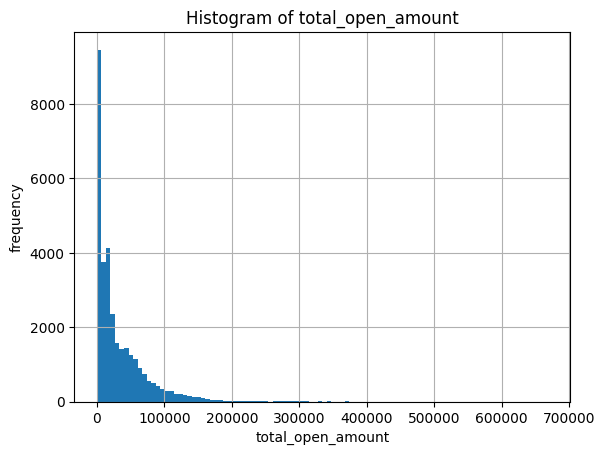

In [130]:
import matplotlib.pyplot as plt

data["total_open_amount"].hist(bins=100)
plt.xlabel("total_open_amount")
plt.ylabel("frequency")
plt.title("Histogram of total_open_amount")
plt.show()

In [131]:
data["total_open_amount"].describe()

count     32000.000000
mean      31883.954124
std       39536.354520
min           0.790000
25%        4645.560000
50%       17175.165000
75%       46206.340000
max      668593.360000
Name: total_open_amount, dtype: float64

In [162]:
import numpy as np

#total_open_amount의 분포가 매우 치우쳐져 있기 때문에, 로그 변환을 통해 분포를 완화하려고 함
data['log_total_open_amount'] = np.log1p(data['total_open_amount'])

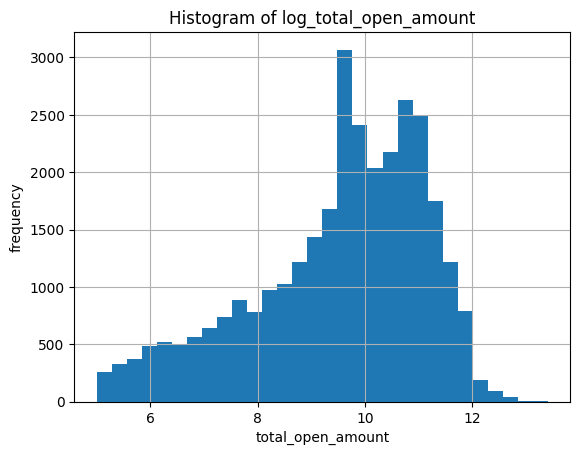

In [165]:
data["log_total_open_amount"].hist(bins=30)
plt.xlabel("total_open_amount")
plt.ylabel("frequency")
plt.title("Histogram of log_total_open_amount")
plt.show()

In [134]:
data["log_total_open_amount"].describe()

count    32000.000000
mean         9.394592
std          1.784011
min          0.582216
25%          8.443882
50%          9.751278
75%         10.740894
max         13.412933
Name: log_total_open_amount, dtype: float64

In [ ]:
#data = data[data['log_total_open_amount'] >= 5]

In [166]:
data.shape

(31293, 19)

In [142]:
data["cust_payment_terms"].value_counts().to_string()

'cust_payment_terms\nNAA8    12520\nNAH4     8189\nCA10     2473\nNAC6     1055\nNAAX      757\nNAM4      720\nNAD1      661\nNAG2      589\nNAU5      574\nNAGD      510\nNA32      493\nNAX2      439\nNAM2      374\nNA10      277\nNAD5      233\nNAVF      180\nNAVE      179\nNAM1      174\nNAAW      123\nNAWU      109\nNAWN       82\nNAVR       79\nNAVQ       75\nNAWP       46\nCA30       37\nNA3B       35\nNAUZ       34\nNAVM       31\nNACB       28\nNA38       22\nNAD4       18\nNABG       18\nNAB1       16\nC106       12\nNAVL       11\nNA9X       10\nNAUP       10\nNA84       10\nBR56        9\nNAVD        8\nNA3F        8\nNATM        7\nNATJ        5\nCAB1        5\nNAWM        4\nNATW        4\nNA25        4\nNATH        3\nB052        3\nNAVC        3\nCAX2        2\nNA31        2\nNA8Q        2\n90M7        2\nNAM3        2\nNATX        2\nNAV9        2\nNATL        2\nNABD        1\nBR12        1\nNAV2        1\nNATK        1\nNAUY        1\nNAD8        1\nNAUW        1\nNATV

In [146]:
data.groupby("cust_payment_terms")["target"].mean().to_string()

'cust_payment_terms\n90M7    0.000000\nB052    0.666667\nBR12    0.000000\nBR56    0.666667\nC106    0.166667\nCA10    0.764254\nCA30    0.324324\nCA60    0.000000\nCAB1    1.000000\nCAX2    0.500000\nMC15    0.000000\nNA10    0.675090\nNA25    0.250000\nNA31    0.000000\nNA32    0.503043\nNA38    0.772727\nNA3B    0.342857\nNA3F    0.750000\nNA84    0.000000\nNA8Q    0.500000\nNA9X    0.100000\nNAA8    0.469329\nNAAW    0.000000\nNAAX    0.235139\nNAB1    0.812500\nNABD    1.000000\nNABG    0.388889\nNAC6    0.299526\nNACB    1.000000\nNAD1    0.382753\nNAD4    0.722222\nNAD5    0.648069\nNAD8    1.000000\nNAG2    0.743633\nNAGD    0.431373\nNAH4    0.242520\nNAM1    0.827586\nNAM2    0.264706\nNAM3    1.000000\nNAM4    0.002778\nNATH    1.000000\nNATJ    1.000000\nNATK    1.000000\nNATL    1.000000\nNATM    1.000000\nNATU    1.000000\nNATV    1.000000\nNATW    1.000000\nNATX    1.000000\nNAU5    0.634146\nNAUP    0.900000\nNAUW    1.000000\nNAUY    1.000000\nNAUZ    0.617647\nNAV2   

In [ ]:
data["cust_payment_terms_grp"] = data["cust_payment_terms"].where(
    data["cust_payment_terms"].map(counts) > 30,
    "Other"
)



In [152]:
data["cust_payment_terms_grp"].value_counts().to_string()

'cust_payment_terms_grp\nNAA8     12520\nNAH4      8189\nCA10      2473\nNAC6      1055\nNAAX       757\nNAM4       720\nNAD1       661\nNAG2       589\nNAU5       574\nNAGD       510\nNA32       493\nNAX2       439\nNAM2       374\nNA10       277\nOther      245\nNAD5       233\nNAVF       180\nNAVE       179\nNAM1       174\nNAAW       123\nNAWU       109\nNAWN        82\nNAVR        79\nNAVQ        75\nNAWP        46\nCA30        37\nNA3B        35\nNAUZ        34\nNAVM        31'

In [154]:
data.groupby("cust_payment_terms_grp")["target"].mean().to_string()

'cust_payment_terms_grp\nCA10     0.764254\nCA30     0.324324\nNA10     0.675090\nNA32     0.503043\nNA3B     0.342857\nNAA8     0.469329\nNAAW     0.000000\nNAAX     0.235139\nNAC6     0.299526\nNAD1     0.382753\nNAD5     0.648069\nNAG2     0.743633\nNAGD     0.431373\nNAH4     0.242520\nNAM1     0.827586\nNAM2     0.264706\nNAM4     0.002778\nNAU5     0.634146\nNAUZ     0.617647\nNAVE     0.463687\nNAVF     0.716667\nNAVM     0.709677\nNAVQ     0.600000\nNAVR     0.379747\nNAWN     0.500000\nNAWP     0.000000\nNAWU     0.357798\nNAX2     1.000000\nOther    0.648980'